# Statystyki opisowe - jedna zmienna

## Jedna zmienna bez podziału na kategorie

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


<Axes: xlabel='tip', ylabel='Count'>

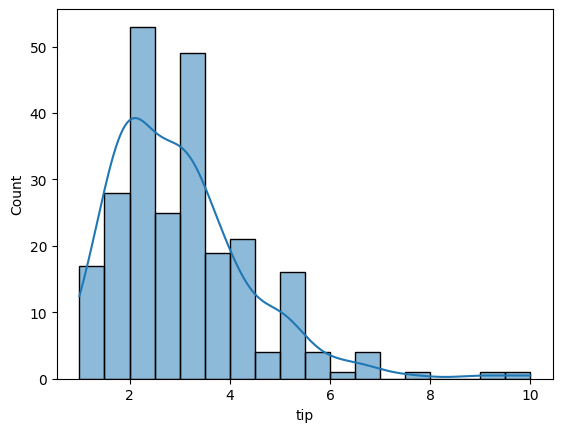

In [1]:
import seaborn as sns # pakiet do wizualizacji danych
import pandas as pd

df = sns.load_dataset('tips')
print(df.info())
print(df.head())
sns.histplot(data=df, x="tip", kde=True)

In [6]:
import scipy.stats as st
import numpy as np

# Wybieramy zmienną
dane = df['total_bill']

# 1. Obliczamy niezbędne statystyki
srednia_proby = dane.mean()       # średnia
n = len(dane)                     # wielkość próby

# 2. Wyznaczamy 95% przedział ufności
b_standardowy = st.sem(dane) # sem = standard error of the mean
przedzial_ufnosci = st.t.interval(confidence=0.95, df=n-1, loc=srednia_proby, scale=b_standardowy)

# 3. Wyświetlenie wyników

print(f"Średnia z próby: {srednia_proby:.2f}")
print(f"95% Przedział ufności: ({przedzial_ufnosci[0]:.2f}, {przedzial_ufnosci[1]:.2f})")


Średnia z próby: 19.79
95% Przedział ufności: (18.66, 20.91)


In [7]:
df['tip'].describe() # metoda w Pandas

,tip
count,244.000000
mean,2.998279
std,1.383638
min,1.000000
25%,2.000000
50%,2.900000
75%,3.562500
max,10.000000


In [8]:
import numpy as np

df1 = pd.DataFrame(
    data = [[1, 2],
            [3, 4],
            [5, np.nan]],   # NaN w drugiej kolumnie
    index = ['arek', 'darek', 'marek'],
    columns = ['zł', '$']
)

print(df1)

       zł    $
arek    1  2.0
darek   3  4.0
marek   5  NaN


In [9]:
df1.describe()

,zł,$
count,3.0,2.000000
mean,3.0,3.000000
std,2.0,1.414214
min,1.0,2.000000
25%,2.0,2.500000
50%,3.0,3.000000
75%,4.0,3.500000
max,5.0,4.000000


In [10]:
df1.isna().sum()

,0
zł,0
$,1


In [11]:
df['tip'].isna().sum()  # nie ma braków danych

np.int64(0)

In [12]:
df['tip'].describe(percentiles=[0.1, 0.9, 0.95])  # percentyle

,tip
count,244.000000
mean,2.998279
std,1.383638
min,1.000000
10%,1.500000
50%,2.900000
90%,5.000000
95%,5.195500
max,10.000000


In [13]:
df['tip'].quantile(.1)

np.float64(1.5)

In [14]:
df['tip'].quantile([.9, .95])

,tip
0.90,5.0000
0.95,5.1955


In [15]:
df['tip'].mean()
# sum, median, mode, std, var, skew, kurt,

np.float64(2.99827868852459)

In [16]:
print(df['tip'].median())
print(df['tip'].std())
print(df['tip'].var())
print(df['tip'].skew())   # 0.5 - 1 umiarkowana prawostronna
print(df['tip'].kurt())

2.9
1.3836381890011826
1.9144546380624725
1.4654510370979401
3.648375873352852


In [17]:
print(df['tip'].mode()) # 0 - pierwsza (i ostatnia) dominanta, 2 - najczęściej pojawia się dwa (wartość mody)

0    2.0
Name: tip, dtype: float64


In [18]:
df["tip"].value_counts() # liczebność mody 33

,count
tip,
2.00,33
3.00,23
4.00,12
2.50,10
5.00,10
...,...
1.47,1
1.17,1
4.67,1


In [19]:
df['smoker'].describe()   # zmienne jakościowe

,smoker
count,244
unique,2
top,No
freq,151


In [20]:
df["smoker"].value_counts()

,count
smoker,
No,151
Yes,93


In [21]:
import statistics as stat # zwykle importuje się jako stats
stat.stdev(df['tip']) # Calculates the standard deviation from a sample of data

1.383638189001182

In [22]:
stat.pstdev(df['tip']) # Calculates the standard deviation from an entire population


1.3807999538298952

In [23]:
from scipy import stats
stats.describe(df['tip'])

DescribeResult(nobs=np.int64(244), minmax=(np.float64(1.0), np.float64(10.0)), mean=np.float64(2.99827868852459), variance=np.float64(1.9144546380624712), skewness=np.float64(1.4564266884221506), kurtosis=np.float64(3.5495519893455114))

## Jedna zmienna z podziałem na kategorie

In [24]:
df.query('sex == "Female"')[['tip']].mean()   # [[ ]] zwraca ramkę danych

,0
tip,2.833448


In [25]:
df.query('sex == "Male"')['tip'].mean()     # [] zwraca liczbę

np.float64(3.0896178343949043)

In [26]:
df.groupby("sex")["tip"].describe()

/tmp/ipykernel_2033/199809758.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sex")["tip"].describe()


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Male,157.0,3.089618,1.489102,1.0,2.0,3.00,3.76,10.0
Female,87.0,2.833448,1.159495,1.0,2.0,2.75,3.50,6.5


In [27]:
df.groupby("sex")["tip"].agg(
    ["count", "mean", "median", "std", "var", "skew", pd.Series.kurt, lambda x: x.quantile(0.95)]
    )
# skew zadziała ,ale samo "kurt" już nie
# funkcja anonimowa - weź kolumna tip jako x i oblicz z tej kolumny (x) percentyl

/tmp/ipykernel_2033/684750927.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sex")["tip"].agg(


,count,mean,median,std,var,skew,kurt,<lambda_0>
sex,,,,,,,,
Male,157,3.089618,3.00,1.489102,2.217424,1.590084,3.784475,5.864
Female,87,2.833448,2.75,1.159495,1.344428,0.683951,0.243652,5.000


In [28]:
df.groupby("sex")["tip"].agg(
    częstość = "count",
     średnia = "mean",
     mediana = "median",
     odchylenie_standardowe = "std",
     wariancja = "var",
     skośność = "skew",
     kurtoza = pd.Series.kurt,
     percentyl_95 = lambda x: x.quantile(0.95),
     minimum = "min",
     maksimum = "max"
    )


/tmp/ipykernel_2033/2294399453.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sex")["tip"].agg(


,częstość,średnia,mediana,odchylenie_standardowe,wariancja,skośność,kurtoza,percentyl_95,minimum,maksimum
sex,,,,,,,,,,
Male,157,3.089618,3.00,1.489102,2.217424,1.590084,3.784475,5.864,1.0,10.0
Female,87,2.833448,2.75,1.159495,1.344428,0.683951,0.243652,5.000,1.0,6.5


In [29]:
statystyki_opisowe = df.groupby("sex")["tip"].agg(
    częstość = "count",
    braki_danych = lambda x: x.isna().sum(),
    średnia = "mean",
    mediana = "median",
    odchylenie_standardowe = "std",
    wariancja = "var",
    skośność = "skew",
    kurtoza = pd.Series.kurt,
    kwantyl_95 = lambda x: x.quantile(0.95),
    minimum = "min",
    maksimum = "max"
    )
statystyki_opisowe.T # transponowanie kolumny <-> wiersze

/tmp/ipykernel_2033/554730367.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  statystyki_opisowe = df.groupby("sex")["tip"].agg(


sex,Male,Female
częstość,157.000000,87.000000
braki_danych,0.000000,0.000000
średnia,3.089618,2.833448
mediana,3.000000,2.750000
odchylenie_standardowe,1.489102,1.159495
wariancja,2.217424,1.344428
skośność,1.590084,0.683951
kurtoza,3.784475,0.243652
kwantyl_95,5.864000,5.000000
minimum,1.000000,1.000000


# Wykresy i tabele

# Testowanie hipotez

In [30]:
import pandas as pd
import numpy as np
df = pd.read_excel('https://github.com/zarkadiuszem/student/raw/main/mieszkania.xlsx')
df.head(5)

,cena_wynajmu,liczba_metrów,dzielnica,liczba_osób,ocena_standardu,internet,minimalny_okres_wynajmu,kaucja,wymagane_poręczenie,rodzaj_ogrzewania,data_wynajmu,dostęp_miejsce_parking,uwagi
0,807,48,Zachód,3,Średni,Tak,1,True,1,centralne,2026-04-30,Nie,Brak
1,1659,73,Prawobrzeże,6,Wysoki,Tak,3,True,0,prąd,2026-04-20,Nie,Brak
2,1350,69,Północ,5,Średni,Tak,10,True,0,węgiel,2026-03-26,Nie,Brak
3,1784,65,Północ,4,Średni,Tak,9,True,0,centralne,2026-02-17,Nie,Brak
4,991,57,Północ,2,Niski,Tak,7,True,0,gazowe,2026-04-04,Nie,"Dobre ocieplenie, niskie koszty ogrzewania"


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   cena_wynajmu             356 non-null    int64 
 1   liczba_metrów            356 non-null    int64 
 2   dzielnica                356 non-null    object
 3   liczba_osób              356 non-null    object
 4   ocena_standardu          356 non-null    object
 5   internet                 356 non-null    object
 6   minimalny_okres_wynajmu  356 non-null    object
 7   kaucja                   356 non-null    bool  
 8   wymagane_poręczenie      356 non-null    int64 
 9   rodzaj_ogrzewania        356 non-null    object
 10  data_wynajmu             356 non-null    object
 11  dostęp_miejsce_parking   356 non-null    object
 12  uwagi                    356 non-null    object
dtypes: bool(1), int64(3), object(9)
memory usage: 33.9+ KB


In [32]:
# podział na dwie grupy
grupa_kaucja = df[df["kaucja"] == True]["cena_wynajmu"]
grupa_brak_kaucji = df[df["kaucja"] == False]["cena_wynajmu"]
grupa_brak_kaucji


,cena_wynajmu
7,1166
8,2430
9,1518
11,2552
13,800
...,...
341,800
342,800
345,1624
348,800


In [33]:
print("Średnia cena (kaucja=True):", grupa_kaucja.mean())
print("Średnia cena (kaucja=False):", grupa_brak_kaucji.mean())

Średnia cena (kaucja=True): 1332.2466960352424
Średnia cena (kaucja=False): 1459.5736434108528


## Algorytm wyboru testu statystycznego

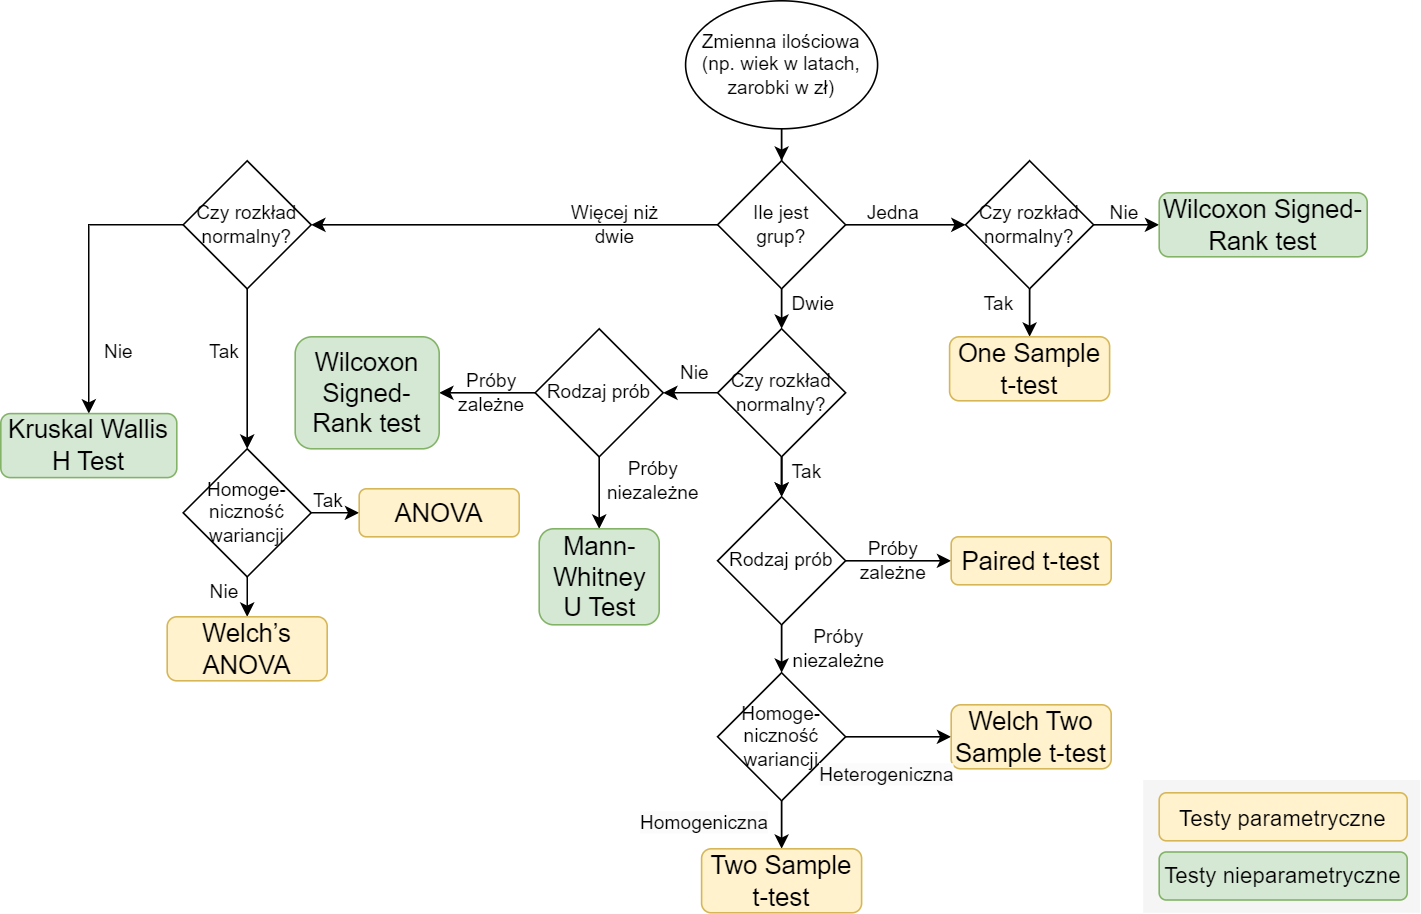

## Testowanie normalności rozkładu

In [34]:
# sprawdzenie normalności rozkładu - przykład z wygenerowanych danych
x = np.random.normal(0, 1, 10000)


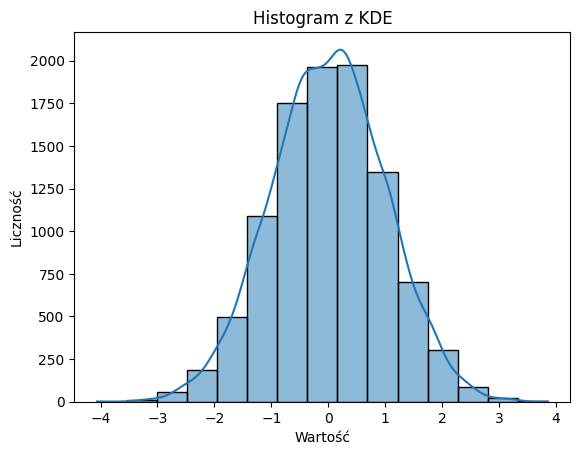

In [35]:
# jak wygląda rozkład normalny
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(x, bins=15, kde=True)

plt.title("Histogram z KDE")
plt.xlabel("Wartość")
plt.ylabel("Liczność")
plt.show()

In [36]:
# sprawdzenie normalności rozkładu
from scipy.stats import shapiro # test Shapiro
print(shapiro(grupa_kaucja))
print(shapiro(grupa_brak_kaucji))
# H0: nasz rozkład jest zgodny z rozkładem normalnym
# dla obu kategorii odrzucamy H0

ShapiroResult(statistic=np.float64(0.7841825099194887), pvalue=np.float64(5.4180341213186684e-17))
ShapiroResult(statistic=np.float64(0.8660208541252629), pvalue=np.float64(1.9556644593441552e-09))


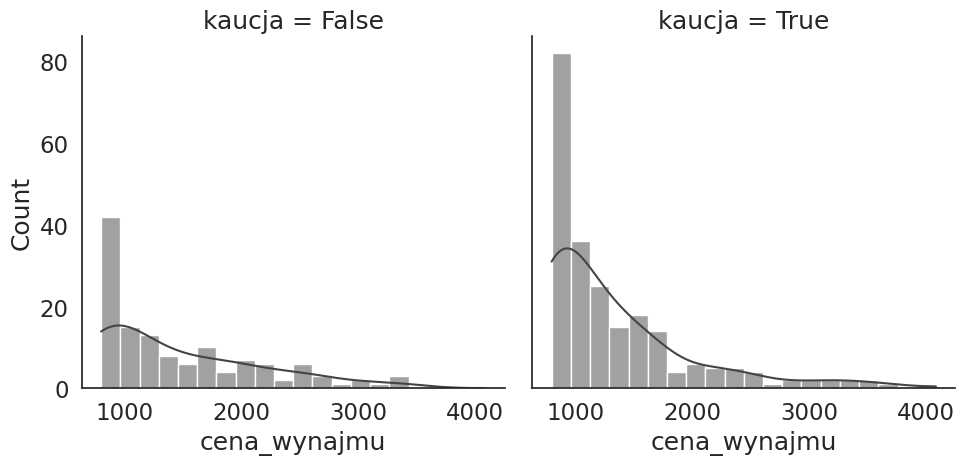

In [37]:
# ocena na bazie histogramu
sns.set_context('notebook', font_scale=1.5)# paper, notebook, talk, poster
sns.set_style('white')  # white, dark, whitegrid, darkgrid, ticks
sns.displot(data = df, x = 'cena_wynajmu', bins = 20,
            kde = True, col = 'kaucja', color='#444444')
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

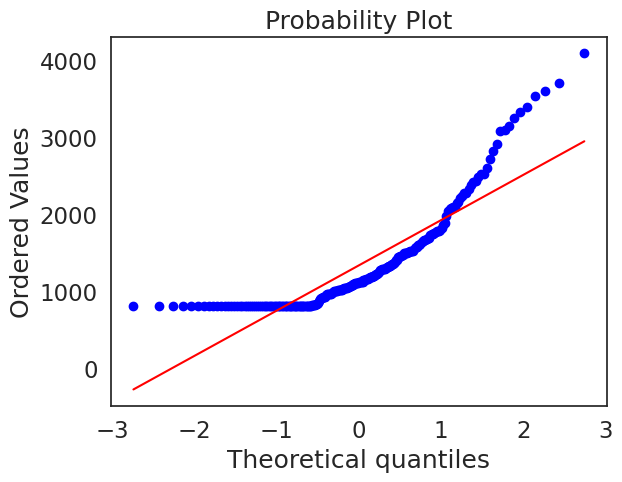

In [38]:
import scipy.stats as stats
stats.probplot(grupa_kaucja, dist="norm", plot=plt)
plt.show()

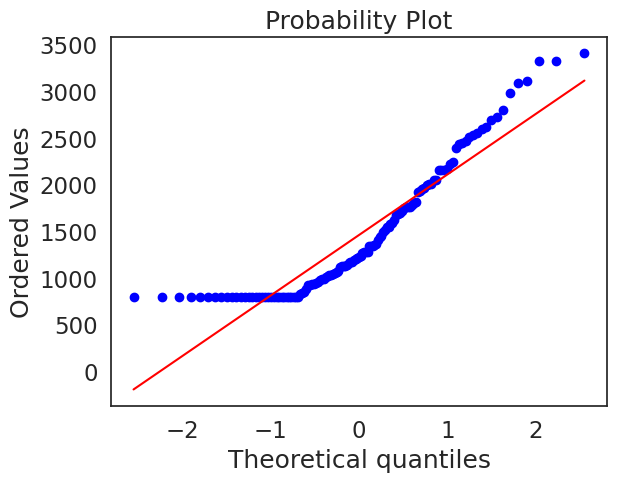

In [39]:
stats.probplot(grupa_brak_kaucji, dist="norm", plot=plt)
plt.show()

## Test nieparametryczny Mann–Whitney U

In [40]:
# brak rozkładu normalnego - test nieparametryczny
from scipy.stats import mannwhitneyu # test nieparametryczny Mann–Whitney U
print(mannwhitneyu(grupa_kaucja, grupa_brak_kaucji, alternative="two-sided"))
stat, p = mannwhitneyu(grupa_kaucja, grupa_brak_kaucji, alternative="two-sided")
print("U =", stat)
print("p-value =", p)

MannwhitneyuResult(statistic=np.float64(13059.0), pvalue=np.float64(0.08721822236343008))
U = 13059.0
p-value = 0.08721822236343008


## Testowanie homogeniczności wariancji

In [41]:
# zakładamy (wbrew wcześniejszym ustaleniom), że przyjmujemy założenie o normalności rozkładu
from scipy.stats import levene # test levena
stat, p_value = levene(grupa_kaucja, grupa_brak_kaucji)

print("Statystyka Levene’a:", stat)
print("p-value:", p_value)

Statystyka Levene’a: 2.484947542228609
p-value: 0.11583337522959547


In [42]:
alpha = 0.05

if p_value < alpha:
    print("Odrzucamy H0 – wariancje różnią się istotnie.")
else:
    print("Brak podstaw do odrzucenia H0 – wariancje można uznać za równe.")

Brak podstaw do odrzucenia H0 – wariancje można uznać za równe.


## Test t-Studenta

In [43]:
# sytuacja 1 - gdy wariancje są różne
# test t-Studenta (wersja Welch - bez założenia równych wariancji)
from scipy.stats import ttest_ind
stat, p_value = ttest_ind(grupa_kaucja, grupa_brak_kaucji, equal_var=False)

print("Statystyka t:", stat)
print("p-value:", p_value)

Statystyka t: -1.7065844417458902
p-value: 0.08910694002155864


In [44]:
# sytuacja 2 - gdy wariancje są równe
# test t-Studenta (homogeniczna wariancja)
from scipy.stats import ttest_ind
stat, p_value = ttest_ind(grupa_kaucja, grupa_brak_kaucji, equal_var=True)

print("Statystyka t:", stat)
print("p-value:", p_value)

Statystyka t: -1.726266793704819
p-value: 0.08517191269237041


In [45]:
alpha = 0.05

if p_value < alpha:
    print("Istnieje statystycznie istotna różnica cen wynajmu.")
else:
    print("Brak podstaw do stwierdzenia istotnej różnicy cen.")

Brak podstaw do stwierdzenia istotnej różnicy cen.


## ANOVA - analysis of variance

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

df = pd.read_excel('https://github.com/zarkadiuszem/student/raw/main/mieszkania.xlsx')
df.head(5)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   cena_wynajmu             356 non-null    int64 
 1   liczba_metrów            356 non-null    int64 
 2   dzielnica                356 non-null    object
 3   liczba_osób              356 non-null    object
 4   ocena_standardu          356 non-null    object
 5   internet                 356 non-null    object
 6   minimalny_okres_wynajmu  356 non-null    object
 7   kaucja                   356 non-null    bool  
 8   wymagane_poręczenie      356 non-null    int64 
 9   rodzaj_ogrzewania        356 non-null    object
 10  data_wynajmu             356 non-null    object
 11  dostęp_miejsce_parking   356 non-null    object
 12  uwagi                    356 non-null    object
dtypes: bool(1), int64(3), object(9)
memory usage: 33.9+ KB


<Axes: xlabel='dzielnica', ylabel='cena_wynajmu'>

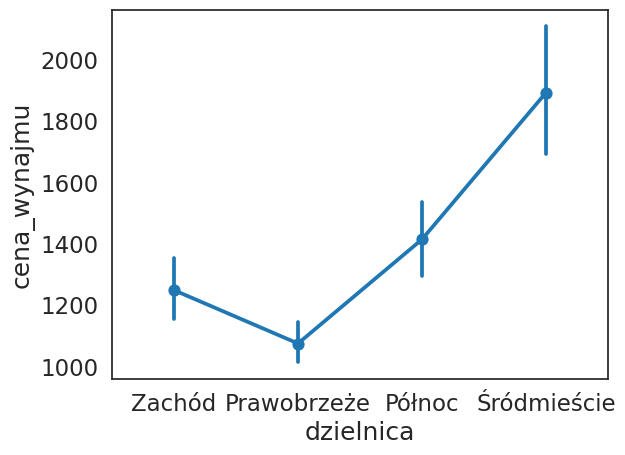

In [47]:
# wizualizacja średnich dla kolejnych grup
sns.pointplot(
    data=df,
    x="dzielnica",
    y="cena_wynajmu",
    errorbar=("ci", 95)
)


In [48]:
# porównanie średnich
import pandas as pd
df.groupby("dzielnica")["cena_wynajmu"].mean()

,cena_wynajmu
dzielnica,
Prawobrzeże,1074.591837
Północ,1414.308511
Zachód,1248.600000
Śródmieście,1892.918919


<Axes: xlabel='dzielnica', ylabel='cena_wynajmu'>

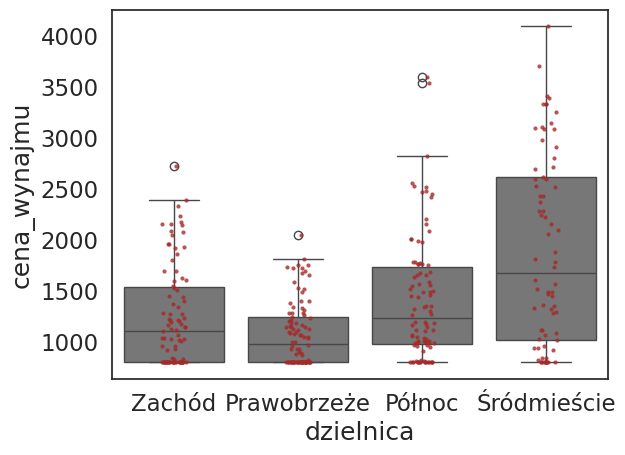

In [49]:
# wzrokowa ocena podziału i jednorodności wariancji
sns.boxplot(data=df,
            x="dzielnica",
            y="cena_wynajmu",
            color = "#777777")
sns.stripplot(
    data=df,
    x="dzielnica",
    y="cena_wynajmu",
    color="brown",
    alpha=0.8,
    jitter=True,
    size = 3
)

In [50]:
# podgląd liczebności grup - liczebności powinny być porównywalne

print(df["dzielnica"].value_counts())
# stosunek największej do najmniejszej nie powinien być większy niż 1.5
98/74 # założenie spełnione

dzielnica
Prawobrzeże    98
Północ         94
Zachód         90
Śródmieście    74
Name: count, dtype: int64


1.3243243243243243

In [51]:

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols # ols - Ordinary Least Squares

# ANOVA
model = ols('cena_wynajmu ~ C(dzielnica)', data=df).fit()
# C - traktuj jako kategorię
# fit - dopasuj model

anova_table = sm.stats.anova_lm(model, typ=2)
# typ = 2 - jak liczyć sumę kwadratów

print(anova_table)

# PR(>F) jest mniejsze niż 0.05 = ceny wynajmu różnią się w sposób istotny
# ale nie wiadomo które

                    sum_sq     df          F        PR(>F)
C(dzielnica)  3.027287e+07    3.0  27.434059  5.757259e-16
Residual      1.294747e+08  352.0        NaN           NaN


In [52]:
# założenie o normalności reszt - nie jest spełnione
stats.shapiro(model.resid)

ShapiroResult(statistic=np.float64(0.9476261153441407), pvalue=np.float64(6.448973845340539e-10))

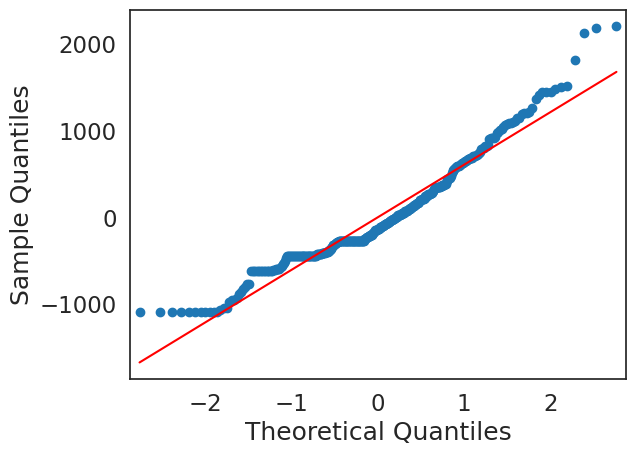

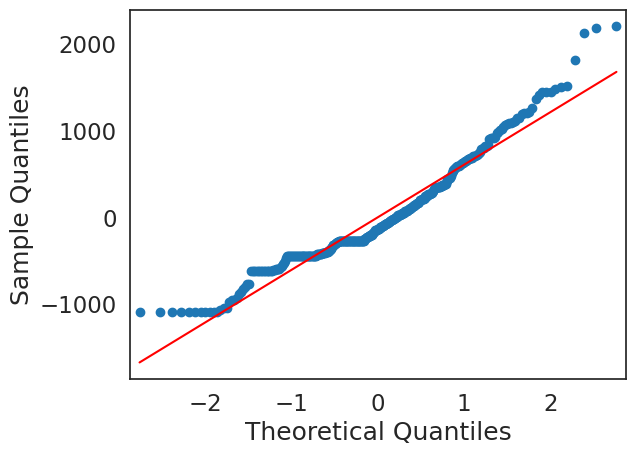

In [53]:
# sprawdzamy dodatkowo QQ-plot - ponownie widać naruszenie założenia
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(model.resid, line='s')

In [54]:
# drugie założenie o homogeniczności wariancji
groups = [
    group["cena_wynajmu"].dropna()
    for name, group in df.groupby("dzielnica")
]
print(groups)
# tworzymy listę, w której przechowywane są 4 elementy - zawierające
#dane (cenę wynajmu) z kolejnych dzielnic


[1      1659
10      800
12     1151
13      800
20     1267
       ... 
336    1719
339     800
341     800
344    1491
348     800
Name: cena_wynajmu, Length: 98, dtype: int64, 2      1350
3      1784
4       991
6      1172
7      1166
       ... 
342     800
347     800
349    1689
353    1438
355    1326
Name: cena_wynajmu, Length: 94, dtype: int64, 0       807
5       800
16     1115
23     1220
27     1196
       ... 
338    1269
340    1145
345    1624
346    2329
351    1954
Name: cena_wynajmu, Length: 90, dtype: int64, 8      2430
18     2803
19     1064
21      846
29      800
       ... 
334    1350
343    1329
350    1608
352    1570
354    1085
Name: cena_wynajmu, Length: 74, dtype: int64]


In [55]:
stats.levene(*groups) # gwiazdka rozpakowuje listę
#
# wariancje nie są jednorodne
# oba założenia nie są spełnione

LeveneResult(statistic=np.float64(32.36196723072212), pvalue=np.float64(1.6961366563854037e-18))

In [56]:
# dlatego test nieparametryczny - test Kruskala-Wallisa
groups = [
    group["cena_wynajmu"].dropna()
    for _, group in df.groupby("dzielnica")
]
# tworzymy grupy tak samo
# _ oznacza ignorowanie dzielnicy (nie jest potrzebna nazwa dzielnicy)

stats.kruskal(*groups)



KruskalResult(statistic=np.float64(45.33725910535828), pvalue=np.float64(7.844904122359918e-10))

In [57]:
# są istotne statystycznie różnice - ale między którymi?
# wtedy stosujemy Dunn test - co już wymaga doinstalowania modułu scikit_posthocs
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(
    df,
    val_col="cena_wynajmu",
    group_col="dzielnica",
    p_adjust="bonferroni"  # albo "holm"
)

print(posthoc)

ModuleNotFoundError: No module named 'scikit_posthocs'

In [58]:
# a gdyby założenia ANOVA były spełnione
# szukamy, które różnice są istotne statystycznie (między którymi parami)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["cena_wynajmu"],
    groups=df["dzielnica"],
    alpha=0.05
)

print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2    meandiff p-adj   lower    upper   reject
-----------------------------------------------------------------
Prawobrzeże      Północ  339.7167 0.0007 113.6998 565.7335   True
Prawobrzeże      Zachód  174.0082 0.2032 -54.5579 402.5743  False
Prawobrzeże Śródmieście  818.3271    0.0 577.2241  1059.43   True
     Północ      Zachód -165.7085 0.2506 -396.591  65.1739  False
     Północ Śródmieście  478.6104    0.0 235.3104 721.9104   True
     Zachód Śródmieście  644.3189    0.0  398.649 889.9889   True
-----------------------------------------------------------------
